In [1]:
import polars as pl
import pandas as pd

In [2]:
df = (
    pl.scan_csv("data/rating_complete.csv")
    .collect()
)

In [3]:
df.head()

user_id,anime_id,rating
i64,i64,i64
0,430,9
0,1004,5
0,3010,7
0,570,7
0,2762,9


In [4]:
df.shape

(57633278, 3)

In [5]:
df = pd.read_csv("data/rating_complete.csv")
df.shape

(57633278, 3)

In [6]:
"""import pandas as pd

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse, mae

# Keep only required columns
ratings = df[['user_id', 'anime_id', 'rating']]

reader = Reader(rating_scale=(ratings.rating.min(), ratings.rating.max()))

data = Dataset.load_from_df(
    ratings[['user_id', 'anime_id', 'rating']],
    reader
)

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

model.fit(trainset)

predictions = model.test(testset)

print("RMSE:", rmse(predictions))
print("MAE :", mae(predictions))"""

'import pandas as pd\n\nfrom surprise import Dataset\nfrom surprise import Reader\nfrom surprise import SVD\nfrom surprise.model_selection import train_test_split\nfrom surprise.accuracy import rmse, mae\n\n# Keep only required columns\nratings = df[[\'user_id\', \'anime_id\', \'rating\']]\n\nreader = Reader(rating_scale=(ratings.rating.min(), ratings.rating.max()))\n\ndata = Dataset.load_from_df(\n    ratings[[\'user_id\', \'anime_id\', \'rating\']],\n    reader\n)\n\ntrainset, testset = train_test_split(\n    data,\n    test_size=0.2,\n    random_state=42\n)\n\nmodel = SVD(\n    n_factors=100,\n    n_epochs=20,\n    lr_all=0.005,\n    reg_all=0.02,\n    random_state=42\n)\n\nmodel.fit(trainset)\n\npredictions = model.test(testset)\n\nprint("RMSE:", rmse(predictions))\nprint("MAE :", mae(predictions))'

### BENCHMARK

In [7]:
"""from surprise.accuracy import rmse, mae

rmse_value = rmse(predictions, verbose=False)
mae_value = mae(predictions, verbose=False)

rating_range = ratings["rating"].max() - ratings["rating"].min()

rmse_pct = (rmse_value / rating_range) * 100
mae_pct = (mae_value / rating_range) * 100

print(f"RMSE: {rmse_value:.3f} ({rmse_pct:.2f}%)")
print(f"MAE : {mae_value:.3f} ({mae_pct:.2f}%)")"""

'from surprise.accuracy import rmse, mae\n\nrmse_value = rmse(predictions, verbose=False)\nmae_value = mae(predictions, verbose=False)\n\nrating_range = ratings["rating"].max() - ratings["rating"].min()\n\nrmse_pct = (rmse_value / rating_range) * 100\nmae_pct = (mae_value / rating_range) * 100\n\nprint(f"RMSE: {rmse_value:.3f} ({rmse_pct:.2f}%)")\nprint(f"MAE : {mae_value:.3f} ({mae_pct:.2f}%)")'

In [8]:
animes = pd.read_csv("data/anime.csv")

In [9]:
animes.shape

(17562, 35)

In [10]:
animes.head()

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,...,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,...,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26,"Jul 2, 2002 to Dec 24, 2002",Summer 2002,...,2182.0,4806.0,10128.0,11618.0,5709.0,2920.0,1083.0,353.0,164.0,131.0
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,TV,52,"Sep 30, 2004 to Sep 29, 2005",Fall 2004,...,312.0,529.0,1242.0,1713.0,1068.0,634.0,265.0,83.0,50.0,27.0


In [11]:
animes_filtered = animes[['MAL_ID',  'Name',  'Genres',  'Rating',  'Studios', 'Type', 'Premiered', 'Source', 'Members']].rename(columns={
    'MAL_ID': 'anime_id',
    'Rating': 'Age_rating'
    })


In [12]:
df.rename(columns={'rating': 'score'}, inplace=True)

In [13]:
animes_filtered.head()

,anime_id,Name,Genres,Age_rating,Studios,Type,Premiered,Source,Members
0,1,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",R - 17+ (violence & profanity),Sunrise,TV,Spring 1998,Original,1251960
1,5,Cowboy Bebop: Tengoku no Tobira,"Action, Drama, Mystery, Sci-Fi, Space",R - 17+ (violence & profanity),Bones,Movie,Unknown,Original,273145
2,6,Trigun,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",PG-13 - Teens 13 or older,Madhouse,TV,Spring 1998,Manga,558913
3,7,Witch Hunter Robin,"Action, Mystery, Police, Supernatural, Drama, ...",PG-13 - Teens 13 or older,Sunrise,TV,Summer 2002,Original,94683
4,8,Bouken Ou Beet,"Adventure, Fantasy, Shounen, Supernatural",PG - Children,Toei Animation,TV,Fall 2004,Manga,13224


In [14]:
df.head()

,user_id,anime_id,score
0,0,430,9
1,0,1004,5
2,0,3010,7
3,0,570,7
4,0,2762,9


In [15]:
df_total = pd.merge(df, animes_filtered, on='anime_id', how='left')

In [16]:
df_total.shape

(57633278, 11)

In [17]:
df_total.head() 

,user_id,anime_id,score,Name,Genres,Age_rating,Studios,Type,Premiered,Source,Members
0,0,430,9,Fullmetal Alchemist: The Conqueror of Shamballa,"Military, Comedy, Historical, Drama, Fantasy, ...",PG-13 - Teens 13 or older,Bones,Movie,Unknown,Manga,279946
1,0,1004,5,Kanojo to Kanojo no Neko,"Drama, Psychological, Romance, Slice of Life",G - All Ages,Unknown,OVA,Unknown,Original,82209
2,0,3010,7,Kaiketsu Zorro,"Adventure, Historical, Shounen",PG-13 - Teens 13 or older,Ashi Production,TV,Spring 1996,Other,9044
3,0,570,7,Jin-Rou,"Military, Police, Psychological, Drama, Romance",R - 17+ (violence & profanity),Production I.G,Movie,Unknown,Manga,124856
4,0,2762,9,Igano Kabamaru,"Action, Adventure, Comedy, Romance, School, Sh...",PG-13 - Teens 13 or older,Group TAC,TV,Fall 1983,Manga,8759


In [18]:
df_total.columns

Index(['user_id', 'anime_id', 'score', 'Name', 'Genres', 'Age_rating',
       'Studios', 'Type', 'Premiered', 'Source', 'Members'],
      dtype='object')

In [19]:
df = df_total.copy()

In [20]:
import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ============================================================
# PARAMETERS
# ============================================================

N_HASH_FEATURES = 128

# ============================================================
# NUMERIC FEATURES
# ============================================================

numeric = csr_matrix(
    df[["score", "Members"]]
    .fillna(0)
    .astype(np.float32)
)

# ============================================================
# HASH GENRES
# ============================================================

genre_hasher = HashingVectorizer(
    n_features=N_HASH_FEATURES,
    binary=True,
    alternate_sign=False,
    token_pattern=r'[^,]+'
)

genre_matrix = genre_hasher.transform(
    df["Genres"].fillna("")
)

# ============================================================
# OTHER CATEGORICAL VARIABLES
# ============================================================

categorical_cols = [
    "Type",
    "Age_rating",
    "Source"
]

encoder = OneHotEncoder(
    handle_unknown="ignore"
)

cat_matrix = encoder.fit_transform(
    df[categorical_cols].fillna("Unknown")
)

# ============================================================
# INTERACTION MATRIX
# ============================================================

X = hstack([
    numeric,
    genre_matrix,
    cat_matrix
]).tocsr()

# ============================================================
# AGGREGATE PER USER
# ============================================================

user_codes, unique_users = pd.factorize(df["user_id"])

n_users = len(unique_users)

aggregation = csr_matrix(
    (
        np.ones(len(df), dtype=np.float32),
        (user_codes, np.arange(len(df)))
    )
)

X_user = aggregation @ X

# Average instead of sum
counts = np.asarray(aggregation.sum(axis=1)).ravel()
counts[counts == 0] = 1

X_user = X_user.multiply(1 / counts[:, None])

# ============================================================
# SCALE
# ============================================================

scaler = StandardScaler(with_mean=False)

X_scaled = scaler.fit_transform(X_user)

"""
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# FIND THE BEST NUMBER OF CLUSTERS
# ============================================================

SAMPLE_SIZE = min(10000, X_scaled.shape[0])

rng = np.random.default_rng(42)
sample_idx = rng.choice(
    X_scaled.shape[0],
    SAMPLE_SIZE,
    replace=False
)

X_sample = X_scaled[sample_idx]

k_values = range(2, 21)

scores = []

for k in k_values:

    model = MiniBatchKMeans(
        n_clusters=k,
        batch_size=10000,
        random_state=42,
        n_init="auto"
    )

    labels = model.fit_predict(X_sample)

    score = silhouette_score(
        X_sample,
        labels,
        metric="euclidean"
    )

    scores.append(score)

    print(f"k = {k:2d} | Silhouette = {score:.4f}")

best_k = k_values[np.argmax(scores)]

print(f"\nBest k = {best_k}")

plt.figure(figsize=(8,5))

plt.plot(k_values, scores, marker="o")

plt.xlabel("Quantidade de Clusters (k)")
plt.ylabel("Score")
plt.title("Teste de Silhuette")

plt.grid(alpha=0.3)

plt.show()

# Use the best value found
N_CLUSTERS = best_k"""

'\nfrom sklearn.cluster import MiniBatchKMeans\nfrom sklearn.metrics import silhouette_score\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# ============================================================\n# FIND THE BEST NUMBER OF CLUSTERS\n# ============================================================\n\nSAMPLE_SIZE = min(10000, X_scaled.shape[0])\n\nrng = np.random.default_rng(42)\nsample_idx = rng.choice(\n    X_scaled.shape[0],\n    SAMPLE_SIZE,\n    replace=False\n)\n\nX_sample = X_scaled[sample_idx]\n\nk_values = range(2, 21)\n\nscores = []\n\nfor k in k_values:\n\n    model = MiniBatchKMeans(\n        n_clusters=k,\n        batch_size=10000,\n        random_state=42,\n        n_init="auto"\n    )\n\n    labels = model.fit_predict(X_sample)\n\n    score = silhouette_score(\n        X_sample,\n        labels,\n        metric="euclidean"\n    )\n\n    scores.append(score)\n\n    print(f"k = {k:2d} | Silhouette = {score:.4f}")\n\nbest_k = k_values[np.argmax(scores)]\n\nprint

   user_id  Cluster
0        0        3
1        1        5
2        2        4
3        3        7
4        4        5


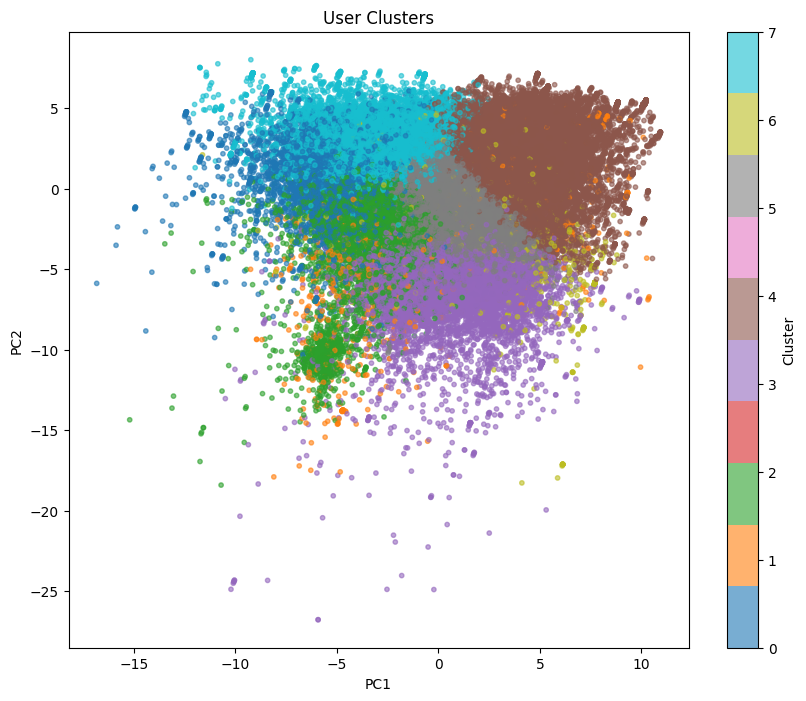

In [21]:
N_CLUSTERS = 8 

# ============================================================
# CLUSTER
# ============================================================

kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    batch_size=10000,
    random_state=42,
    n_init="auto"
)

clusters = kmeans.fit_predict(X_scaled)

# ============================================================
# RESULTS
# ============================================================

users_cluster = pd.DataFrame({
    "user_id": unique_users,
    "Cluster": clusters
})

print(users_cluster.head())

# ============================================================
# PCA VISUALIZATION
# ============================================================

pca = PCA(n_components=2, random_state=42)

X_plot = pca.fit_transform(X_scaled.toarray())

plt.figure(figsize=(10,8))

plt.scatter(
    X_plot[:,0],
    X_plot[:,1],
    c=clusters,
    cmap="tab10",
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("User Clusters")
plt.colorbar(label="Cluster")
plt.show()

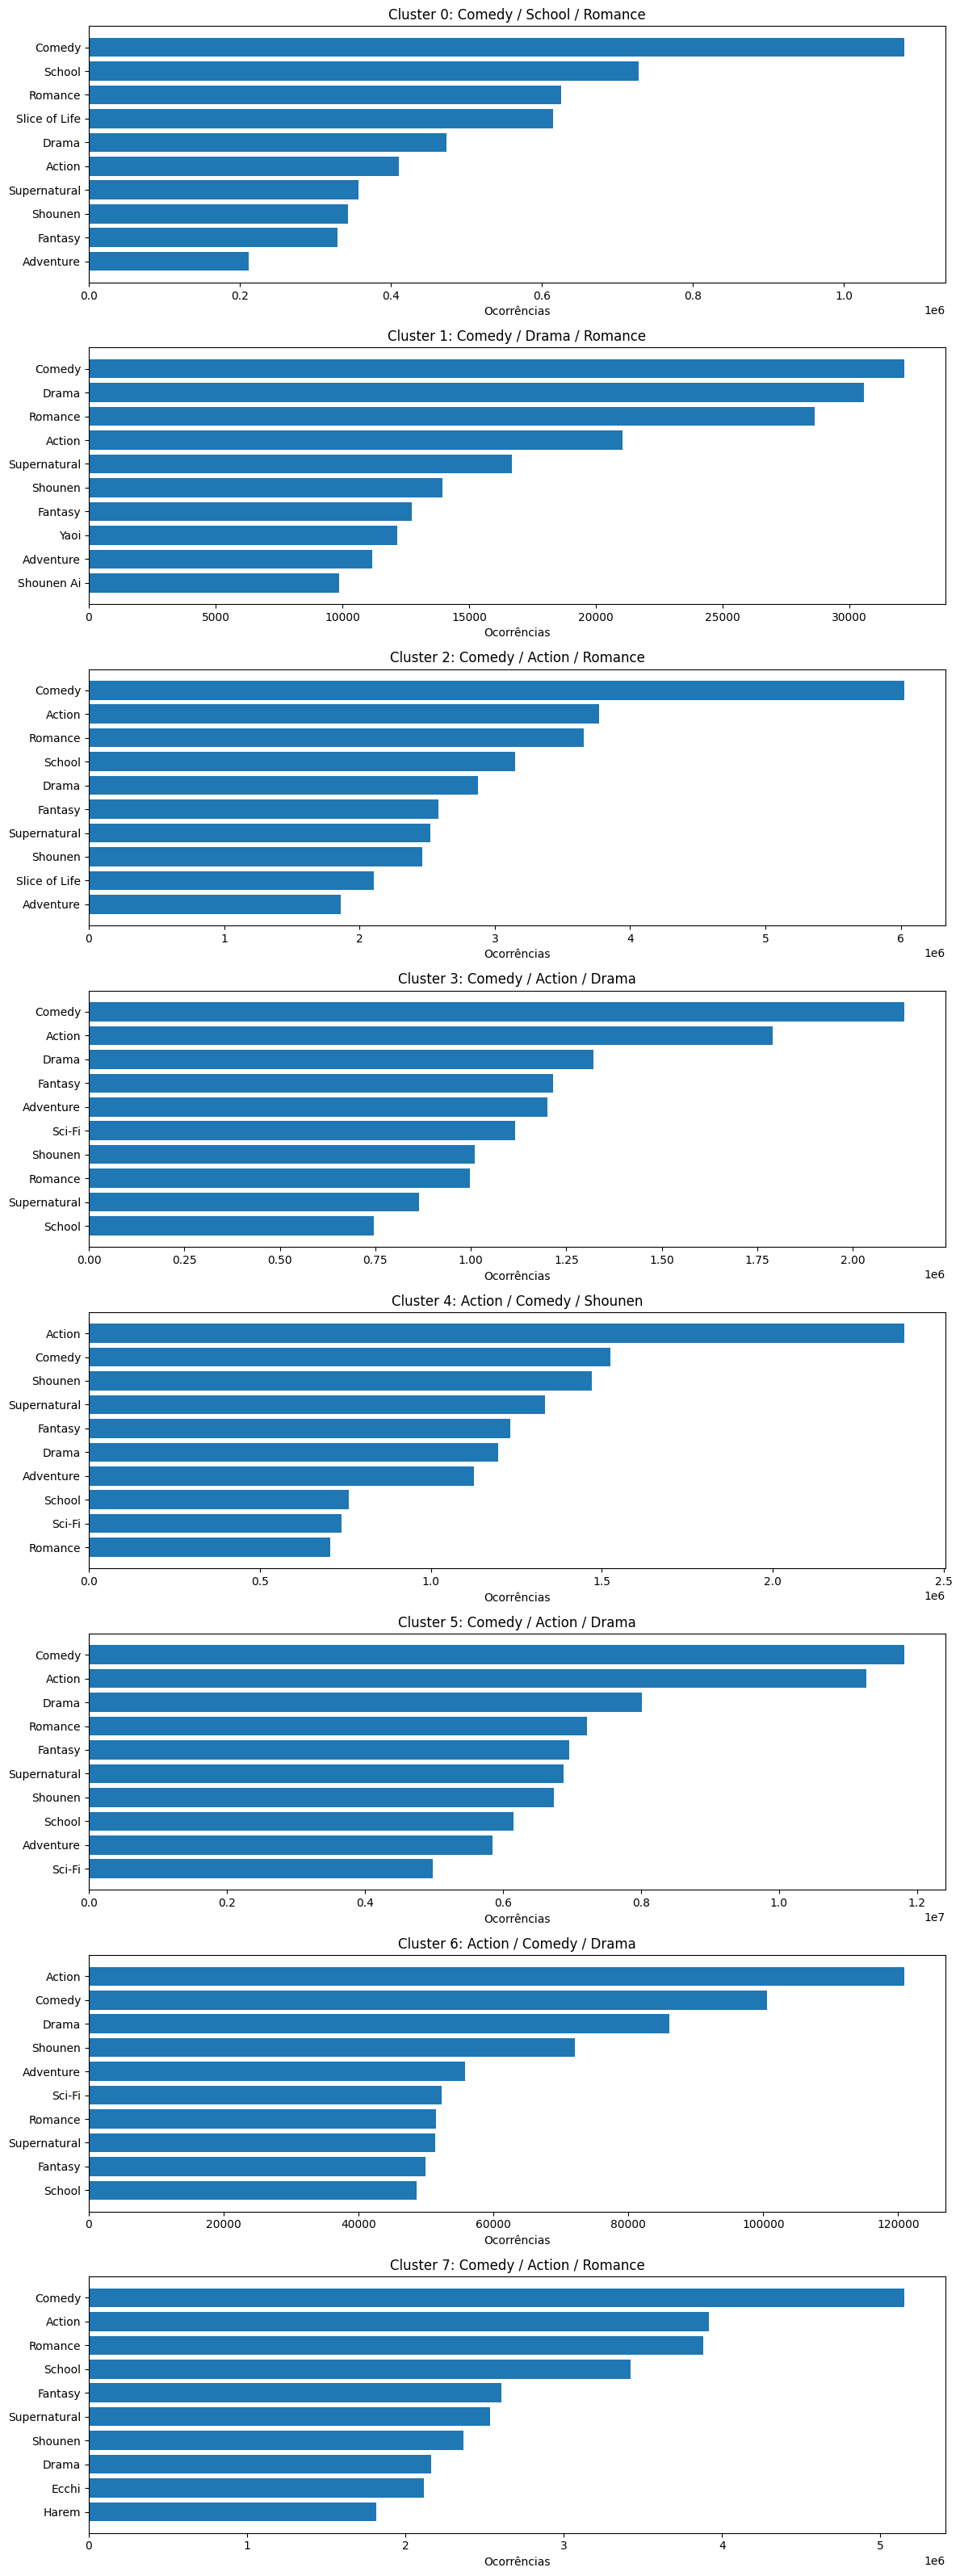

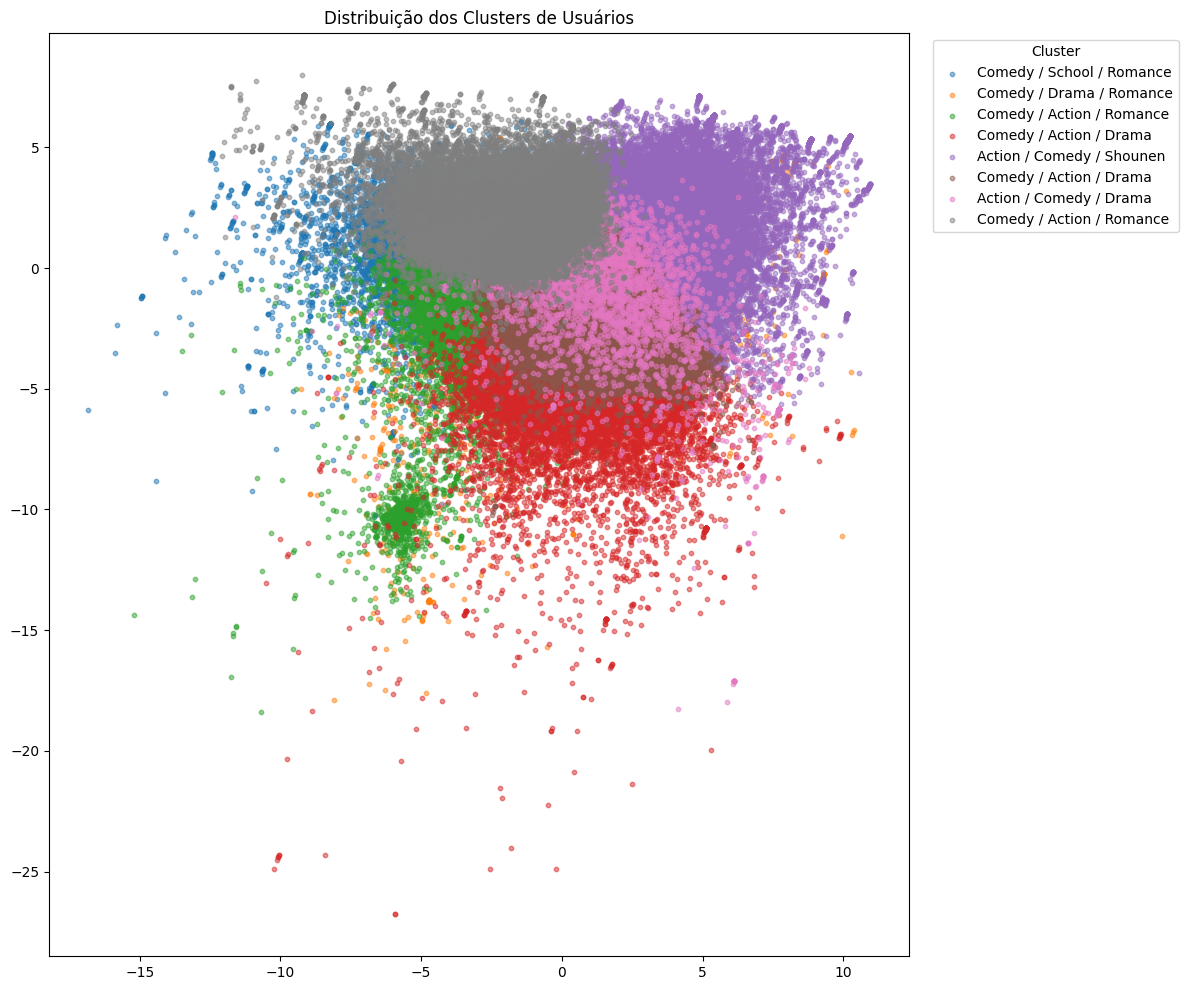


Cluster Summary

Cluster 0
Name: Comedy / School / Romance
   Comedy               1,080,540
   School               728,184
   Romance              625,532
   Slice of Life        615,340
   Drama                473,277
   Action               410,568
   Supernatural         357,627
   Shounen              343,252
   Fantasy              329,297
   Adventure            212,123

Cluster 1
Name: Comedy / Drama / Romance
   Comedy               32,172
   Drama                30,564
   Romance              28,614
   Action               21,039
   Supernatural         16,678
   Shounen              13,943
   Fantasy              12,722
   Yaoi                 12,160
   Adventure            11,171
   Shounen Ai           9,884

Cluster 2
Name: Comedy / Action / Romance
   Comedy               6,027,738
   Action               3,768,970
   Romance              3,656,305
   School               3,147,861
   Drama                2,874,821
   Fantasy              2,584,673
   Supernatural     

In [22]:
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Attach cluster to every interaction
# ============================================================

df = df.merge(users_cluster, on="user_id", how="left")

# ============================================================
# Count genres per cluster (streaming, no explode)
# ============================================================

cluster_genres = defaultdict(Counter)

for cluster, genres in zip(df["Cluster"], df["Genres"]):

    if pd.isna(genres):
        continue

    for genre in genres.split(","):
        cluster_genres[cluster][genre.strip()] += 1

# ============================================================
# Create cluster names
# ============================================================

cluster_names = {}

for cluster in sorted(cluster_genres.keys()):

    top3 = [
        genre
        for genre, _
        in cluster_genres[cluster].most_common(3)
    ]

    cluster_names[cluster] = " / ".join(top3)

# ============================================================
# Plot top genres for each cluster
# ============================================================

n_clusters = len(cluster_names)

fig, axes = plt.subplots(
    n_clusters,
    1,
    figsize=(12, 4*n_clusters)
)

if n_clusters == 1:
    axes = [axes]

for ax, cluster in zip(axes, sorted(cluster_names.keys())):

    top10 = cluster_genres[cluster].most_common(10)

    genres = [g for g, _ in top10]
    counts = [c for _, c in top10]

    ax.barh(genres, counts)

    ax.invert_yaxis()

    ax.set_title(
        f"Cluster {cluster}: {cluster_names[cluster]}"
    )

    ax.set_xlabel("Ocorrências")

plt.tight_layout()
plt.show()

# ============================================================
# PCA with cluster names
# ============================================================

plt.figure(figsize=(12, 10))

for cluster in sorted(cluster_names.keys()):

    idx = clusters == cluster

    plt.scatter(
        X_plot[idx, 0],
        X_plot[idx, 1],
        s=10,
        alpha=0.5,
        label=cluster_names[cluster]
    )

plt.title("Distribuição dos Clusters de Usuários")
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# Print summary
# ============================================================

print("\nCluster Summary\n")

for cluster in sorted(cluster_names.keys()):

    print(f"Cluster {cluster}")
    print(f"Name: {cluster_names[cluster]}")

    for genre, count in cluster_genres[cluster].most_common(10):
        print(f"   {genre:<20} {count:,}")

    print()